>>> Nutze Super-Gauss als 2D-Eingangsfeld
!!!lens!!!
!!!propagate over distance!!! 8.0
!!!lens!!!
!!!propagate over distance!!! 8.135593220338983
!!!lens!!!
!!!propagate over distance!!! 8.271186440677965
!!!lens!!!
!!!propagate over distance!!! 8.40677966101695
!!!lens!!!
!!!propagate over distance!!! 8.542372881355933
!!!lens!!!
!!!propagate over distance!!! 8.677966101694915
!!!lens!!!
!!!propagate over distance!!! 8.813559322033898
!!!lens!!!
!!!propagate over distance!!! 8.94915254237288
!!!lens!!!
!!!propagate over distance!!! 9.084745762711865
!!!lens!!!
!!!propagate over distance!!! 9.220338983050848
!!!lens!!!
!!!propagate over distance!!! 9.35593220338983
!!!lens!!!
!!!propagate over distance!!! 9.491525423728813
!!!lens!!!
!!!propagate over distance!!! 9.627118644067796
!!!lens!!!
!!!propagate over distance!!! 9.76271186440678
!!!lens!!!
!!!propagate over distance!!! 9.898305084745763
!!!lens!!!
!!!propagate over distance!!! 10.033898305084746
!!!lens!!!
!!!propagate over di

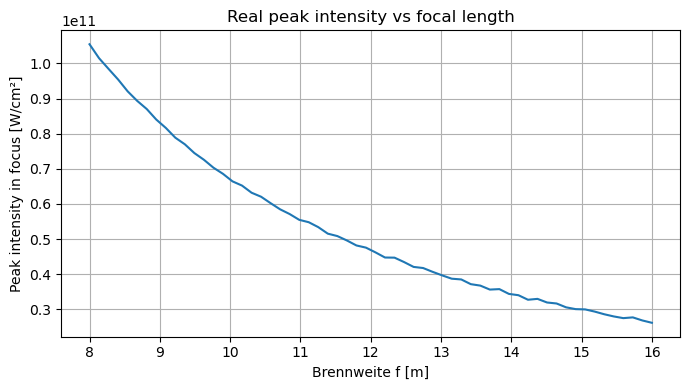

Peak at f = 8.000 m
I_max = 1.055e+15 W/m²
I_max = 1.055e+11 W/cm²


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os
from matplotlib.colors import LogNorm

# ==============================================================
# 0) SCHALTER & PARAMETER
# ==============================================================
lam       = 1064e-9        # Wellenlänge [m]
BEAM_DIAM = 11e-3          # physikalischer Strahldurchmesser im Objektraum [m]
f         = 5.0            # Brennweite [m]

# Simulationsparameter (1024x1024)
N   = 1024                 # Stützstellen pro Achse
L   = 3 * BEAM_DIAM        # Simulationsfensterbreite im Objektraum [m]
dx  = L / N
x   = (np.arange(N) - N/2) * dx
y   = x
X, Y = np.meshgrid(x, y)
w0  = BEAM_DIAM / 2        # w-Parameter des Super-Gauss (nur als Default)

# ==============================================================
# 1) WCF-READER (2D-PROFIL)
# ==============================================================
def read_wcf_frames(filepath):
    frames = []
    FILE_HEADER  = 5592
    FRAME_HEADER = 944

    with open(filepath, "rb") as fobj:
        fobj.seek(FILE_HEADER)
        expected_w = None
        expected_h = None

        while True:
            header = fobj.read(FRAME_HEADER)
            if len(header) < FRAME_HEADER:
                break

            w = struct.unpack_from("<I", header, 20)[0]
            h = struct.unpack_from("<I", header, 24)[0]

            if expected_w is None:
                expected_w, expected_h = w, h

            if w != expected_w or h != expected_h:
                fobj.seek(w*h*2, 1)
                continue

            data = fobj.read(w*h*2)
            if len(data) < w*h*2:
                break

            frames.append(np.frombuffer(data, dtype=np.uint16).reshape((h, w)))

    return np.array(frames)

def extract_2d_profile_from_wcf(filename):
    frames = read_wcf_frames(filename)
    if frames.size == 0:
        raise RuntimeError("Keine gültigen Frames in WCF-Datei!")

    avg = np.mean(frames, axis=0).astype(float)

    bg = np.min(avg)
    avg = avg - bg
    avg[avg < 0] = 0.0

    max_val = np.max(avg)
    if max_val > 0:
        avg /= max_val

    h, w = avg.shape
    return avg, (h, w)

def make_dataprofile(filename="BeamProfile1.wcf"):
    print(">>> Nutze gemessenes WCF-Profil als 2D-Eingangsfeld")
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    profile_wcf, (h_wcf, w_wcf) = extract_2d_profile_from_wcf(filename)
    if (h_wcf, w_wcf) != (N, N):
        raise ValueError(f"WCF-Daten haben Shape {(h_wcf, w_wcf)}, "
                         f"aber Simulation erwartet {(N, N)}.")

    return np.sqrt(np.maximum(profile_wcf, 0.0)).astype(complex)

# ==============================================================
# 2) HILFSFUNKTIONEN: Strahlradius / Profiles / Fits
# ==============================================================
def find_1e2_radius(U, nbins=400):
    """1/e^2-Radius aus 2D-Feld U via radialem Ringmittel."""
    if U.ndim != 2:
        raise ValueError("find_1e2_radius erwartet ein 2D-Feld.")

    I = np.abs(U)**2
    if I.max() == 0:
        return np.nan
    I = I / I.max()

    R = np.sqrt(X**2 + Y**2)
    bins = np.linspace(0, R.max(), nbins)
    r_mid = 0.5 * (bins[:-1] + bins[1:])

    I_radial = np.full(len(r_mid), np.nan)
    for i in range(len(r_mid)):
        m = (R >= bins[i]) & (R < bins[i+1])
        if np.any(m):
            I_radial[i] = np.mean(I[m])

    level = np.exp(-2)
    idx = np.nanargmin(np.abs(I_radial - level))
    return r_mid[idx]

def profile_1d(U, zoom_factor=1.5, eps=1e-12):
    """3 Plots: Gesamt lin, Zoom lin, Zoom log entlang x (mittlere Zeile)."""
    if U.ndim == 2:
        mid = U.shape[0] // 2
        I = np.abs(U[mid, :])**2
        w = find_1e2_radius(U)
    else:
        I = np.abs(U)**2
        w = 2e-3

    x_mm = x * 1e3
    I = I / I.max() if I.max() > 0 else I

    zoom_mm = zoom_factor * w * 1e3
    mask_zoom = np.abs(x_mm) <= zoom_mm if np.isfinite(zoom_mm) else slice(None)

    fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharey=False)

    axs[0].plot(x_mm, I)
    axs[0].set_title("1D – Gesamt (lin)")
    axs[0].set_xlabel("x [mm]")
    axs[0].set_ylabel("norm. Intensität")
    axs[0].grid(True)

    axs[1].plot(x_mm[mask_zoom], I[mask_zoom])
    axs[1].axvline(+zoom_mm, linestyle="--")
    axs[1].axvline(-zoom_mm, linestyle="--")
    axs[1].set_title(f"1D – Zoom ±{zoom_mm:.3f} mm (lin)")
    axs[1].set_xlabel("x [mm]")
    axs[1].set_ylabel("norm. Intensität")
    axs[1].grid(True)

    axs[2].plot(x_mm[mask_zoom], np.maximum(I[mask_zoom], eps))
    axs[2].axvline(+zoom_mm, linestyle="--")
    axs[2].axvline(-zoom_mm, linestyle="--")
    axs[2].set_yscale("log")
    axs[2].set_title(f"1D – Zoom ±{zoom_mm:.3f} mm (log)")
    axs[2].set_xlabel("x [mm]")
    axs[2].set_ylabel("norm. Intensität (log)")
    axs[2].grid(True, which="both")

    plt.tight_layout()
    plt.show()

def profile_2d(U, zoom_factor=1.5, eps=1e-12):
    """3 Plots: 2D Gesamt lin, Zoom lin, Zoom log."""
    if U.ndim != 2:
        raise ValueError("profile_2d erwartet ein 2D-Feld.")

    I = np.abs(U)**2
    I_norm = I / I.max() if I.max() > 0 else I

    w = find_1e2_radius(U)
    zoom_mm = zoom_factor * w * 1e3
    extent = [X.min()*1e3, X.max()*1e3, Y.min()*1e3, Y.max()*1e3]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axs[0].imshow(I_norm, extent=extent, origin="lower", aspect="equal")
    axs[0].set_title("2D – Gesamt (lin)")
    axs[0].set_xlabel("x [mm]")
    axs[0].set_ylabel("y [mm]")
    plt.colorbar(im0, ax=axs[0], fraction=0.046)

    im1 = axs[1].imshow(I_norm, extent=extent, origin="lower", aspect="equal")
    axs[1].set_xlim(-zoom_mm, +zoom_mm)
    axs[1].set_ylim(-zoom_mm, +zoom_mm)
    axs[1].set_title(f"2D – Zoom ±{zoom_mm:.3f} mm (lin)")
    axs[1].set_xlabel("x [mm]")
    axs[1].set_ylabel("y [mm]")
    plt.colorbar(im1, ax=axs[1], fraction=0.046)

    I_log = np.maximum(I_norm, eps)
    im2 = axs[2].imshow(
        I_log,
        extent=extent,
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=eps, vmax=1.0)
    )
    axs[2].set_xlim(-zoom_mm, +zoom_mm)
    axs[2].set_ylim(-zoom_mm, +zoom_mm)
    axs[2].set_title(f"2D – Zoom ±{zoom_mm:.3f} mm (log)")
    axs[2].set_xlabel("x [mm]")
    axs[2].set_ylabel("y [mm]")
    plt.colorbar(im2, ax=axs[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    return I_norm

def mode_overlap(U, U_ref=None):
    """Modenüberlappung mit Referenz-Gauß (TEM00)."""
    if U.ndim != 2:
        raise ValueError(f"mode_overlap erwartet 2D, bekam {U.shape}")

    if U_ref is None:
        R2 = X**2 + Y**2
        U_ref = np.exp(-R2 / w0**2).astype(complex)

    pixel_area = dx * dx
    I  = np.abs(U)**2
    I_ref = np.abs(U_ref)**2
    P  = np.sum(I) * pixel_area
    P_ref = np.sum(I_ref) * pixel_area

    if P == 0 or P_ref == 0:
        print("WARNUNG: Leistung = 0, Modenüberlappung nicht definiert.")
        return 0.0

    overlap = np.sum(U * np.conj(U_ref)) * pixel_area
    eta = np.abs(overlap)**2 / (P * P_ref)

    print("=============================================")
    print("!!!MODE OVERLAP!!!")
    print(f"Mode Overlap η   : {eta:.6f}  ({eta*100:.3f} %)")
    print("=============================================")

    # Profilvergleich
    mid = U.shape[0] // 2
    prof = I[mid, :]
    prof_ref = I_ref[mid, :]
    prof /= prof.max() if prof.max() > 0 else 1
    prof_ref /= prof_ref.max() if prof_ref.max() > 0 else 1

    x_mm = x * 1e3
    plt.figure(figsize=(8,3))
    plt.plot(x_mm, prof, label="Simulation")
    plt.plot(x_mm, prof_ref, '--', label="Referenz")
    plt.xlabel("x [mm]")
    plt.ylabel("norm. Intensity")
    plt.title("Mode Overlap – Profilvergleich")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    return eta

def fit_supergauss_order(U):
    """Schätzt Super-Gauss-Ordnung n (und w) aus 2D-Feld U."""
    if U.ndim != 2:
        raise ValueError(f"fit_supergauss_order erwartet 2D, bekam {U.shape}")

    I = np.abs(U)**2
    if I.max() == 0:
        return None
    I /= I.max()

    R = np.sqrt(X**2 + Y**2)

    mask = (R > 0) & (I > 0) & (I < 0.9)
    r_fit = R[mask]
    i_fit = I[mask]

    if r_fit.size < 10:
        print("WARNUNG: Zu wenige Punkte für verlässlichen Fit.")
        return None

    xx = np.log(r_fit)
    yy = np.log(-np.log(i_fit))

    A = np.vstack([xx, np.ones_like(xx)]).T
    a, b = np.linalg.lstsq(A, yy, rcond=None)[0]

    n_fit = a
    w_fit = np.exp(-b / n_fit)

    print("=============================================")
    print("!!!SUPER-GAUSS FIT!!!")
    print(f"n_fit     : {n_fit:.3f}")
    print(f"w_fit [mm]: {w_fit*1e3:.3f}")
    print("=============================================")

    return n_fit

# ==============================================================
# 3) FELDQUELLEN
# ==============================================================
def make_supergauss(n_order):
    print(">>> Nutze Super-Gauss als 2D-Eingangsfeld")
    R = np.sqrt(X**2 + Y**2)
    return np.exp(-(np.abs(R)/w0)**n_order).astype(complex)

# ==============================================================
# 4) PROPAGATION & LINSE
# ==============================================================
def propagate(U, dz):
    """2D Angular-Spectrum-Propagation über Distanz dz."""
    print("!!!propagate over distance!!!", dz)
    if dz == 0:
        return U

    k  = 2 * np.pi / lam
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2 * np.pi * FX
    ky = 2 * np.pi * FY

    kz_sq = k**2 - kx**2 - ky**2
    kz    = np.sqrt(kz_sq + 0j)
    H = np.exp(1j * kz * dz)

    U_k  = np.fft.fft2(U)
    Uz_k = U_k * H
    Uz   = np.fft.ifft2(Uz_k)
    return Uz

def lens(U, f_local=None):
    """Dünne Linse im Ortsraum (2D)."""
    print("!!!lens!!!")
    if f_local is None:
        f_local = f
    k = 2 * np.pi / lam
    phase_lens = np.exp(-1j * k * (X**2 + Y**2) / (2 * f_local))
    return U * phase_lens

# ==============================================================
# 5) APODIZER: serrated (gezackt)
# ==============================================================
def apodizer_serrated(U, R0=None, depth=0.2, n_teeth=32):
    print("!!!apodizer_serrated!!!")
    if R0 is None:
        R0 = BEAM_DIAM / 2.0

    R = np.sqrt(X**2 + Y**2)
    Phi = np.arctan2(Y, X)

    edge_radius = R0 * (1.0 + depth * np.sign(np.cos(n_teeth * Phi)))
    mask = (R <= edge_radius).astype(float)
    return U * mask

# ==============================================================
# 6) PINHOLE (Maske) + Transmission/Loss
# ==============================================================
def pinhole(U, pinhole_radius):
    """Pinhole-Maske (hier im aktuellen Realraumgitter) + Transmission/Loss."""
    R = np.sqrt(X**2 + Y**2)
    mask = (R <= pinhole_radius)
    U_filtered = U * mask

    I_before = np.abs(U)**2
    I_after  = np.abs(U_filtered)**2
    pixel_area = dx * dx
    P_before = np.sum(I_before) * pixel_area
    P_after  = np.sum(I_after)  * pixel_area
    transmission = P_after / P_before if P_before > 0 else 0.0
    loss = 1 - transmission

    print("=============================================")
    print("!!!pinhole!!!")
    print(f"Pinhole radius: {pinhole_radius*1e3:.3f} mm")
    print(f"Transmission : {transmission*100:.3f} %")
    print(f"Loss        : {loss*100:.3f} %")
    print("=============================================")

    return U_filtered, transmission, loss

# ==============================================================
# 7) DAMAGE-METRIKEN (für gepulst: Fluenz/Peak)
# ==============================================================
def rim_energy_fraction(U_fplane, a, ring_width=None):
    """
    Energieanteil im schmalen Ring um r=a (Fourier-/Pinhole-Ebene).
    ring_width: [m]; wenn None -> 2*dx als Default.
    """
    if ring_width is None:
        ring_width = 2 * dx

    R = np.sqrt(X**2 + Y**2)
    I = np.abs(U_fplane)**2
    pixel_area = dx * dx

    P_total = np.sum(I) * pixel_area
    if P_total <= 0:
        return 0.0

    m = (R >= (a - ring_width/2)) & (R <= (a + ring_width/2))
    P_ring = np.sum(I[m]) * pixel_area
    return P_ring / P_total

def rim_peak_intensity(U_fplane, a, ring_width=None):
    """Max. Intensität im Randring (dimensionslose Skala deines Feldes)."""
    if ring_width is None:
        ring_width = 2 * dx
    R = np.sqrt(X**2 + Y**2)
    I = np.abs(U_fplane)**2
    m = (R >= (a - ring_width/2)) & (R <= (a + ring_width/2))
    if not np.any(m):
        return np.nan
    return np.max(I[m])
E_pulse = 80e-3      # [J]  (80 mJ)
tau     = 100e-12    # [s]  (100 ps)

def pinhole_absorption(U_fplane, pinhole_radius, E_pulse, tau):
    """
    Kreisförmiges Pinhole in der aktuellen Ebene.
    Annahme: alles außerhalb des Lochs wird bei 90° Auftreffen vollständig absorbiert.

    Gibt zurück:
      U_after: gefiltertes Feld
      transmission: Energie-Transmission durch das Loch
      loss: 1-transmission
      metrics: dict mit Fluenz/Intensität (absorbiert) + Karten
    """
    R = np.sqrt(X**2 + Y**2)
    pass_mask  = (R <= pinhole_radius)
    block_mask = ~pass_mask

    I = np.abs(U_fplane)**2
    pixel_area = dx * dx

    # Gesamt-"Energie" in Simulationseinheiten
    P_total = np.sum(I) * pixel_area
    if P_total <= 0:
        U_after = U_fplane * pass_mask
        return U_after, 0.0, 1.0, {
            "E_abs_J": np.nan,
            "F_abs_peak_Jcm2": np.nan,
            "F_abs_mean_Jcm2": np.nan,
            "I_abs_peak_Wcm2": np.nan,
            "I_abs_mean_Wcm2": np.nan
        }

    # Reale Fluenzkarte (J/m^2): F(x,y) = E_pulse * I / ∫I dA
    F_map = (E_pulse * I) / P_total   # [J/m^2]

    # absorbierte Energie = Integral über blockierten Bereich
    E_abs = np.sum(F_map[block_mask]) * pixel_area   # [J]
    # durchgelassene Energie = Integral über Lochbereich
    E_pass = np.sum(F_map[pass_mask]) * pixel_area   # [J]

    transmission = E_pass / E_pulse
    loss = 1 - transmission

    # Absorbierte Fluenz (auf der Platte), Peak und Mean über blockierte Fläche
    A_block = np.sum(block_mask) * pixel_area
    F_abs_peak = np.max(F_map[block_mask])                  # [J/m^2]
    F_abs_mean = (E_abs / A_block) if A_block > 0 else np.nan  # [J/m^2]

    # Intensität aus Fluenz (vereinfachend: Rechteckpuls)
    I_abs_peak = F_abs_peak / tau   # [W/m^2]
    I_abs_mean = F_abs_mean / tau   # [W/m^2]

    # Umrechnung in praxisübliche Einheiten
    metrics = {
        "E_abs_J": E_abs,
        "transmission": transmission,
        "loss": loss,
        "F_abs_peak_Jcm2": F_abs_peak / 1e4,
        "F_abs_mean_Jcm2": F_abs_mean / 1e4,
        "I_abs_peak_Wcm2": I_abs_peak / 1e4,
        "I_abs_mean_Wcm2": I_abs_mean / 1e4,
        # optional für Debug/Plots:
        "F_map_Jcm2": F_map / 1e4,
        "block_mask": block_mask,
        "pass_mask": pass_mask
    }

    U_after = U_fplane * pass_mask
    return U_after, transmission, loss, metrics

# ==============================================================
# 8) OPTIMIZER + HEATMAP (depth vs pinhole)
# ==============================================================
def optimicer_heatmap():
    pinholes = np.arange(0.0005, 0.0008, 0.00005)   # [m]
    depths   = np.arange(0.05, 0.5, 0.05)           # [-]

    Nfit  = np.full((len(depths), len(pinholes)), np.nan)
    Trans = np.full_like(Nfit, np.nan)
    Loss  = np.full_like(Nfit, np.nan)
    Score = np.full_like(Nfit, np.nan)

    # Beispiel: score = n_fit - alpha*loss
    alpha = 2.0

    best = {"score": -np.inf, "depth": None, "pinhole": None, "nfit": None, "trans": None, "loss": None}

    for iy, depth in enumerate(depths):
        for ix, pinhole_size in enumerate(pinholes):

            U = make_supergauss(100)
            U = apodizer_serrated(U, R0=None, depth=depth, n_teeth=32)

            U = propagate(U, 1)
            U = lens(U)
            U = propagate(U, f)        # typischerweise zur Fokus-/Filter-Ebene

            U, trans, loss = pinhole(U, pinhole_size)

            U = propagate(U, f)        # zurück zur nächsten Ebene (vereinfachtes Modell)

            n_fit = fit_supergauss_order(U)
            if n_fit is None or np.isnan(n_fit):
                continue

            score = n_fit - alpha * loss

            Nfit[iy, ix]  = n_fit
            Trans[iy, ix] = trans
            Loss[iy, ix]  = loss
            Score[iy, ix] = score

            if score > best["score"]:
                best.update(score=score, depth=depth, pinhole=pinhole_size, nfit=n_fit, trans=trans, loss=loss)

    def plot_heatmap(Z, title, cbar_label):
        fig, ax = plt.subplots(figsize=(7, 5))
        x_mm = pinholes * 1e3
        y = depths

        im = ax.imshow(Z, origin="lower", aspect="auto",
                       extent=[x_mm.min(), x_mm.max(), y.min(), y.max()])
        ax.set_title(title)
        ax.set_xlabel("pinhole_size [mm]")
        ax.set_ylabel("apodizer depth [-]")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(cbar_label)

        if best["pinhole"] is not None:
            ax.scatter(best["pinhole"]*1e3, best["depth"], marker="x", s=120)
            ax.text(best["pinhole"]*1e3, best["depth"],
                    f"  BEST\n  depth={best['depth']:.2f}\n  pin={best['pinhole']*1e3:.3f}mm",
                    va="bottom")

        plt.tight_layout()
        plt.show()

    plot_heatmap(Score, "Heatmap: Score = n_fit - alpha*loss", "Score [-]")
    plot_heatmap(Nfit,  "Heatmap: Supergauss-Order n_fit",     "n_fit [-]")
    plot_heatmap(Trans, "Heatmap: Transmission",              "Transmission [-]")
    plot_heatmap(Loss,  "Heatmap: Loss",                      "Loss [-]")

    print("\n================ BEST RESULT ================")
    print(f"depth        = {best['depth']:.3f}")
    print(f"pinhole_size = {best['pinhole']*1e3:.3f} mm")
    print(f"n_fit        = {best['nfit']:.3f}")
    print(f"Transmission = {best['trans']*100:.2f} %")
    print(f"Loss         = {best['loss']*100:.2f} %")
    print(f"Score        = {best['score']:.3f}")
    print("============================================\n")

    return best, {"Score": Score, "Nfit": Nfit, "Trans": Trans, "Loss": Loss}, (depths, pinholes)

def physical_intensity(U, E_pulse, tau):
    """
    Gibt reale Intensitätskarte I(x,y) in W/m^2 zurück
    aus dem komplexen Feld U.
    """
    I_sim = np.abs(U)**2
    pixel_area = dx * dx
    P_sim = np.sum(I_sim) * pixel_area   # ∫|U|^2 dA

    if P_sim <= 0:
        return np.zeros_like(I_sim)

    return (E_pulse / tau) * (I_sim / P_sim)


def compute_B_integral(U0, f_local, z_max, nz, n2, E_pulse, tau, use_peak=True):
    """
    Propagiert U0 durch eine dünne Linse und dann bis z_max,
    berechnet I(z) in SI und integriert B = (2π/λ) ∫ n2 I dz.
    n2: m^2/W (konstant) oder Array der Länge nz
    """
    # Linse an z=0
    U = lens(U0, f_local=f_local)

    z = np.linspace(0.0, z_max, nz)
    dz = z[1] - z[0]
    pixel_area = dx * dx

    Ivals = np.zeros_like(z)

    for i in range(nz):
        if i > 0:
            U = propagate(U, dz)

        Isim = np.abs(U)**2
        S = np.sum(Isim) * pixel_area  # ∫ Isim dA

        if S <= 0:
            Ivals[i] = 0.0
            continue

        # Fluenz- und Intensitäts-Skalierung in SI
        F_map = (E_pulse * Isim) / S        # J/m^2
        I_map = F_map / tau                # W/m^2

        if use_peak:
            Ivals[i] = np.max(I_map)
        else:
            # on-axis (mittleres Pixel)
            Ivals[i] = I_map[N//2, N//2]

    # n2(z)
    if np.isscalar(n2):
        n2z = np.full_like(z, float(n2))
    else:
        n2z = np.asarray(n2)
        assert n2z.shape == z.shape

    B = (2*np.pi/lam) * np.trapz(n2z * Ivals, z)  # dimensionslos (rad)
    return z, Ivals, B


def intensity_SI_from_field(U, E_pulse, tau):
    """I_map in W/m^2 aus dimensionslosem Feld U via Energie-Normierung."""
    Isim = np.abs(U)**2
    pixel_area = dx * dx
    S = np.sum(Isim) * pixel_area  # ∫|U|^2 dA
    if S <= 0:
        return np.zeros_like(Isim)
    # Fluenz F=E*|U|^2/∫|U|^2 dA  -> Intensität I=F/tau
    return (E_pulse / tau) * (Isim / S)  # W/m^2


def B_integral_for_f(U0, f_local, z_max, nz, n2_profile, E_pulse, tau, use_peak=True):
    """
    Linse (f_local) bei z=0, dann Propagation bis z_max.
    Integriert B = (2π/λ) ∫ n2(z) * I(z) dz.
    n2_profile: entweder Skalar (konstant) oder Funktion n2(z)->float
    use_peak: True -> I(z)=max(I_map), False -> on-axis I_map[N//2,N//2]
    """
    # 1) Linse anwenden
    U = lens(U0, f_local=f_local)

    # 2) z-Achse + Schritte
    z = np.linspace(0.0, z_max, nz)
    dz = z[1] - z[0]

    I_of_z = np.zeros_like(z)

    for i in range(nz):
        if i > 0:
            U = propagate(U, dz)

        I_map = intensity_SI_from_field(U, E_pulse, tau)
        if use_peak:
            I_of_z[i] = np.max(I_map)
        else:
            I_of_z[i] = I_map[N//2, N//2]

    # 3) n2(z)
    if np.isscalar(n2_profile):
        n2z = np.full_like(z, float(n2_profile))
    else:
        # n2_profile ist Funktion
        n2z = np.array([n2_profile(zi) for zi in z], dtype=float)

    # 4) B-Integral
    B = (2*np.pi/lam) * np.trapz(n2z * I_of_z, z)  # dimensionslos (rad)
    return B, z, I_of_z


def B_vs_focal_length(U0, f_values, z_max_factor, nz, n2_profile, E_pulse, tau, use_peak=True):
    """
    Rechnet B(f) für alle f_values.
    z_max_factor: z_max = z_max_factor * f  (z.B. 1.0 bis Fokus, 2.0 um Fokus herum weiter)
    """
    Bvals = np.zeros_like(f_values, dtype=float)
    Ipeak = np.zeros_like(f_values, dtype=float)

    for i, f_local in enumerate(f_values):
        z_max = z_max_factor * f_local
        B, z, I_of_z = B_integral_for_f(
            U0=U0, f_local=f_local, z_max=z_max, nz=nz,
            n2_profile=n2_profile, E_pulse=E_pulse, tau=tau,
            use_peak=use_peak
        )
        Bvals[i] = B
        Ipeak[i] = np.max(I_of_z)

    return Bvals, Ipeak

# ==============================================================
# 9) BEISPIEL-WORKFLOW
# ==============================================================
if __name__ == "__main__":

    U0 = make_supergauss(100)  # oder make_dataprofile(...)

    f_values = np.linspace(1.0, 10.0, 30)  # [m]

    # Beispielwerte (bitte durch deine Materialien ersetzen!)
    n2_air   = 3.0e-23   # m^2/W (grobe Größenordnung)
    # n2_sio2 = 2.2e-20  # m^2/W (grobe Größenordnung)

    Bvals, Ipeak = B_vs_focal_length(
        U0=U0,
        f_values=f_values,
        z_max_factor=1.0,   # bis z=f (Fokus-Ebene)
        nz=250,
        n2_profile=n2_air,
        E_pulse=E_pulse,
        tau=tau,
        use_peak=True       # Peak-Intensität (worst case)
    )

    plt.figure(figsize=(7,4))
    plt.plot(f_values, Bvals, marker=".")
    plt.xlabel("Brennweite f [m]")
    plt.ylabel("B-Integral [rad]")
    plt.title("B(f) aus Simulation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



